# 02 · EDA — Favorita Grocery Sales

Ziel: Die Zeitreihenstruktur verstehen, bevor wir Features bauen. Konkret:
- Wie sieht die Verteilung der Transaktionen aus?
- Welche Saisonalitäten existieren (Wochentag, Monat, Jahr)?
- Gibt es einen Trend?
- Wie stark korrelieren externe Regressoren (Ölpreis, Feiertage)?
- Wie stark ist die Autokorrelation — und welche Lags sind relevant?

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
PROCESSED = Path('..') / '02_data' / 'processed'

In [2]:
tx     = pl.read_parquet(PROCESSED / 'transactions_long.parquet')
stores = pl.read_parquet(PROCESSED / 'stores.parquet')
oil    = pl.read_parquet(PROCESSED / 'oil.parquet')
hol    = pl.read_parquet(PROCESSED / 'holidays.parquet')

# Arbeits-DataFrame: Transactions + Store-Metadaten + Zeitfeatures
df = (
    tx.join(stores, on='store_nbr', how='left')
    .with_columns([
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.month().alias('month'),
        pl.col('date').dt.year().alias('year'),
    ])
)

print('Shape:', df.shape)
df.head(5)

Shape: (83488, 10)


date,store_nbr,transactions,city,state,type,cluster,weekday,month,year
date,i64,i64,str,str,str,i64,i8,i8,i32
2013-01-01,25,770,"""Salinas""","""Santa Elena""","""D""",1,2,1,2013
2013-01-02,1,2111,"""Quito""","""Pichincha""","""D""",13,3,1,2013
2013-01-02,2,2358,"""Quito""","""Pichincha""","""D""",13,3,1,2013
2013-01-02,3,3487,"""Quito""","""Pichincha""","""D""",8,3,1,2013
2013-01-02,4,1922,"""Quito""","""Pichincha""","""D""",9,3,1,2013


## 1 · Verteilung der Transaktionen

C:\Users\maxkr\AppData\Local\Temp\ipykernel_16480\412426848.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x='type', y='transactions', order=order,


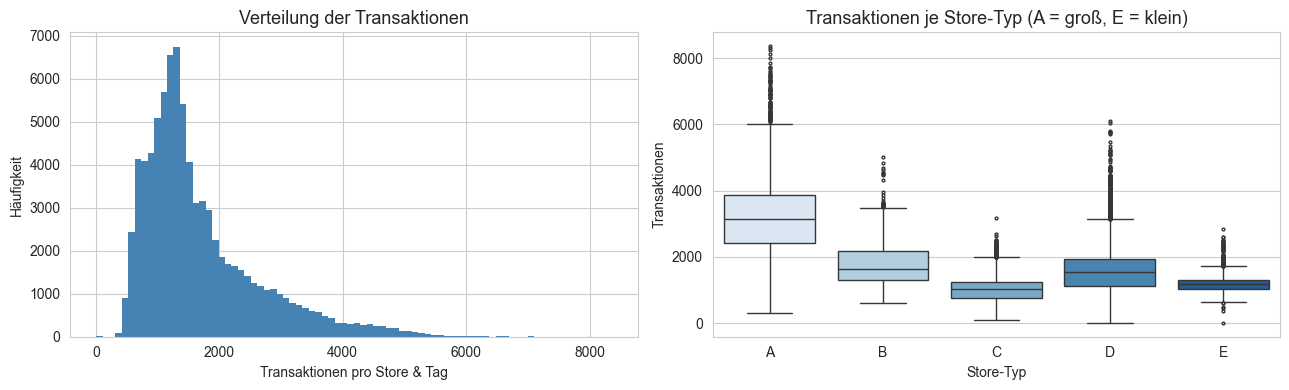

        mean     std  median
type                        
A     3193.1  1038.5  3137.5
B     1756.0   540.4  1645.0
C     1032.1   314.5  1017.0
D     1619.1   705.1  1531.0
E     1188.0   225.2  1164.0


In [3]:
df_pd = df.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramm
axes[0].hist(df_pd['transactions'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Verteilung der Transaktionen', fontsize=13)
axes[0].set_xlabel('Transaktionen pro Store & Tag')
axes[0].set_ylabel('Häufigkeit')

# Boxplot je Store-Typ
order = ['A', 'B', 'C', 'D', 'E']
sns.boxplot(data=df_pd, x='type', y='transactions', order=order,
            palette='Blues', flierprops={'markersize': 2}, ax=axes[1])
axes[1].set_title('Transaktionen je Store-Typ (A = groß, E = klein)', fontsize=13)
axes[1].set_xlabel('Store-Typ')
axes[1].set_ylabel('Transaktionen')

plt.tight_layout()
plt.show()

print(df_pd.groupby('type')['transactions'].agg(['mean','std','median']).round(1))

## 2 · Trend — Jahresentwicklung

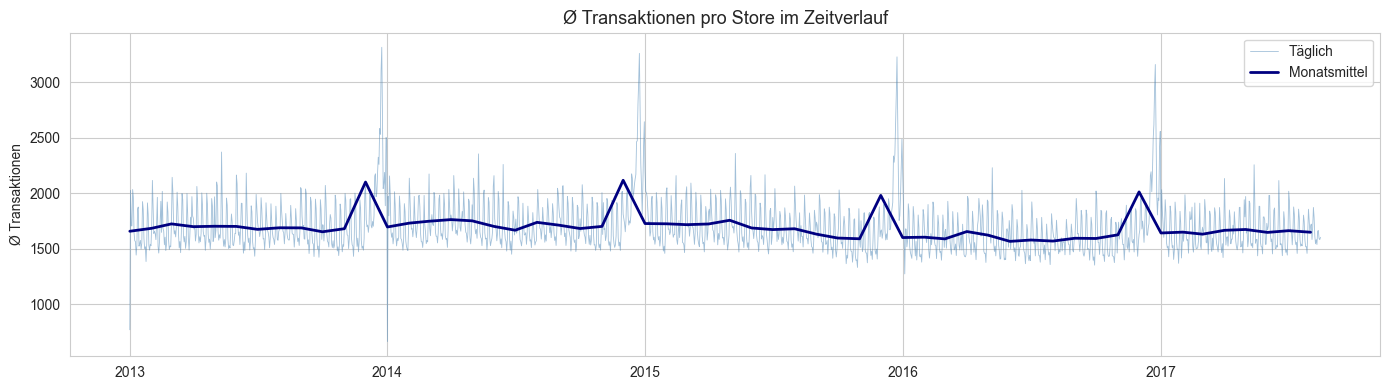

Jährlicher Mittelwert:
shape: (5, 2)
┌──────┬──────────────┐
│ year ┆ transactions │
│ ---  ┆ ---          │
│ i32  ┆ f64          │
╞══════╪══════════════╡
│ 2013 ┆ 1721.5       │
│ 2014 ┆ 1750.9       │
│ 2015 ┆ 1706.8       │
│ 2016 ┆ 1634.4       │
│ 2017 ┆ 1653.3       │
└──────┴──────────────┘


In [4]:
# Täglicher Gesamtverlauf (alle Stores)
daily_total = (
    df.group_by('date')
    .agg(pl.col('transactions').mean().alias('avg_transactions'))
    .sort('date')
    .to_pandas()
)

# Monatlicher Trend als Glättung
monthly_avg = (
    df.with_columns(pl.col('date').dt.truncate('1mo').alias('month_start'))
    .group_by('month_start')
    .agg(pl.col('transactions').mean().alias('avg_transactions'))
    .sort('month_start')
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_total['date'], daily_total['avg_transactions'],
        color='steelblue', linewidth=0.6, alpha=0.5, label='Täglich')
ax.plot(monthly_avg['month_start'], monthly_avg['avg_transactions'],
        color='navy', linewidth=2, label='Monatsmittel')
ax.set_title('Ø Transaktionen pro Store im Zeitverlauf', fontsize=13)
ax.set_ylabel('Ø Transaktionen')
ax.legend()
plt.tight_layout()
plt.show()

print('Jährlicher Mittelwert:')
print(df.group_by('year').agg(pl.col('transactions').mean().round(1)).sort('year'))

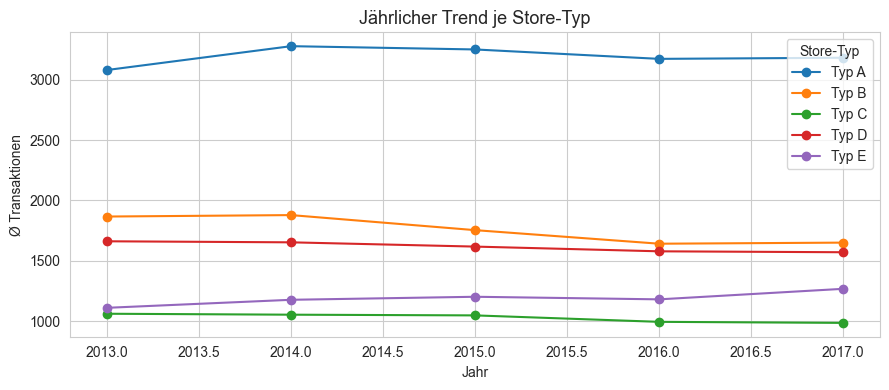

In [5]:
# Trend je Store-Typ: Wächst jeder Typ gleich?
type_year = (
    df.group_by(['year', 'type'])
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort(['type', 'year'])
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(9, 4))
for t, grp in type_year.groupby('type'):
    ax.plot(grp['year'], grp['avg'], marker='o', label=f'Typ {t}', linewidth=1.5)
ax.set_title('Jährlicher Trend je Store-Typ', fontsize=13)
ax.set_ylabel('Ø Transaktionen')
ax.set_xlabel('Jahr')
ax.legend(title='Store-Typ')
plt.tight_layout()
plt.show()

## 3 · Saisonalität — Wochentag & Monat

C:\Users\maxkr\AppData\Local\Temp\ipykernel_16480\2823073443.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_avg, x='label', y='avg', palette='Blues_d', ax=axes[0])
C:\Users\maxkr\AppData\Local\Temp\ipykernel_16480\2823073443.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=month_avg, x='month', y='avg', palette='Blues_d', ax=axes[1])


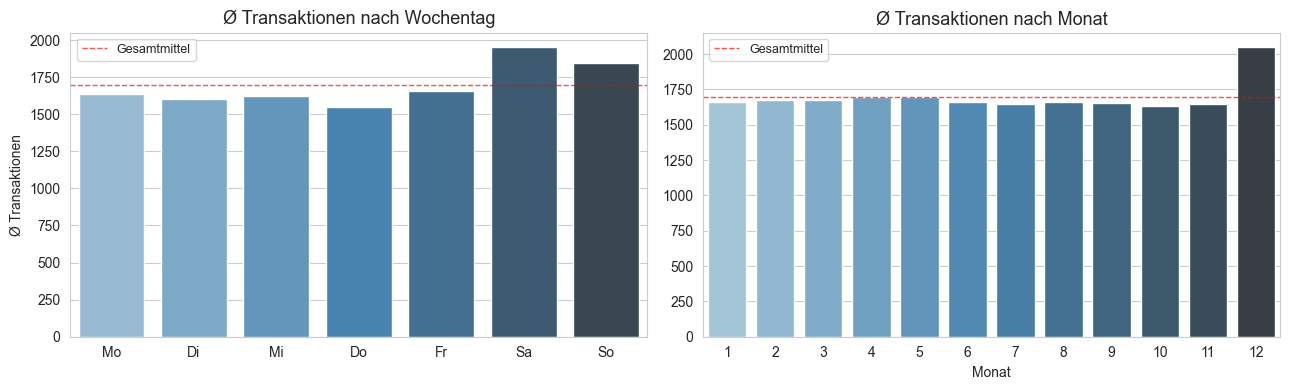

Wochentag-Index (Sa/So vs. Mittelwert):
label  index
   Mo   96.5
   Di   94.5
   Mi   95.7
   Do   91.5
   Fr   97.6
   Sa  115.2
   So  109.0


In [6]:
weekday_avg = (
    df.group_by('weekday')
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort('weekday')
    .to_pandas()
)
weekday_avg['label'] = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']

month_avg = (
    df.group_by('month')
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort('month')
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=weekday_avg, x='label', y='avg', palette='Blues_d', ax=axes[0])
axes[0].set_title('Ø Transaktionen nach Wochentag', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Ø Transaktionen')
axes[0].axhline(weekday_avg['avg'].mean(), color='red', linestyle='--',
                linewidth=1, alpha=0.7, label='Gesamtmittel')
axes[0].legend(fontsize=9)

sns.barplot(data=month_avg, x='month', y='avg', palette='Blues_d', ax=axes[1])
axes[1].set_title('Ø Transaktionen nach Monat', fontsize=13)
axes[1].set_xlabel('Monat')
axes[1].set_ylabel('')
axes[1].axhline(month_avg['avg'].mean(), color='red', linestyle='--',
                linewidth=1, alpha=0.7, label='Gesamtmittel')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Wochentag-Index (Sa/So vs. Mittelwert):')
mean_val = weekday_avg['avg'].mean()
weekday_avg['index'] = (weekday_avg['avg'] / mean_val * 100).round(1)
print(weekday_avg[['label', 'index']].to_string(index=False))

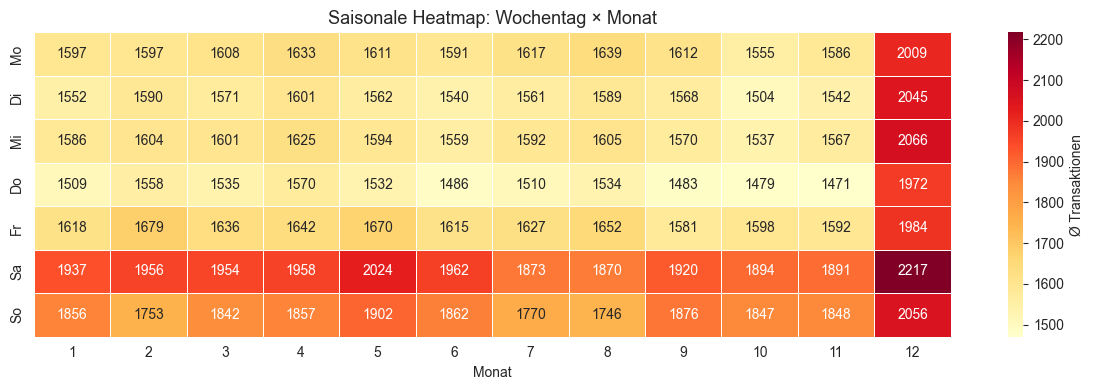

In [7]:
# Saisonales Muster: Heatmap Wochentag × Monat
heatmap_data = (
    df.group_by(['month', 'weekday'])
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort(['month', 'weekday'])
    .to_pandas()
    .pivot(index='weekday', columns='month', values='avg')
)
heatmap_data.index = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Ø Transaktionen'})
ax.set_title('Saisonale Heatmap: Wochentag × Monat', fontsize=13)
ax.set_xlabel('Monat')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 4 · Autokorrelation — welche Lags sind relevant?

Das ist entscheidend für die Feature-Engineering-Entscheidungen in Notebook 03.

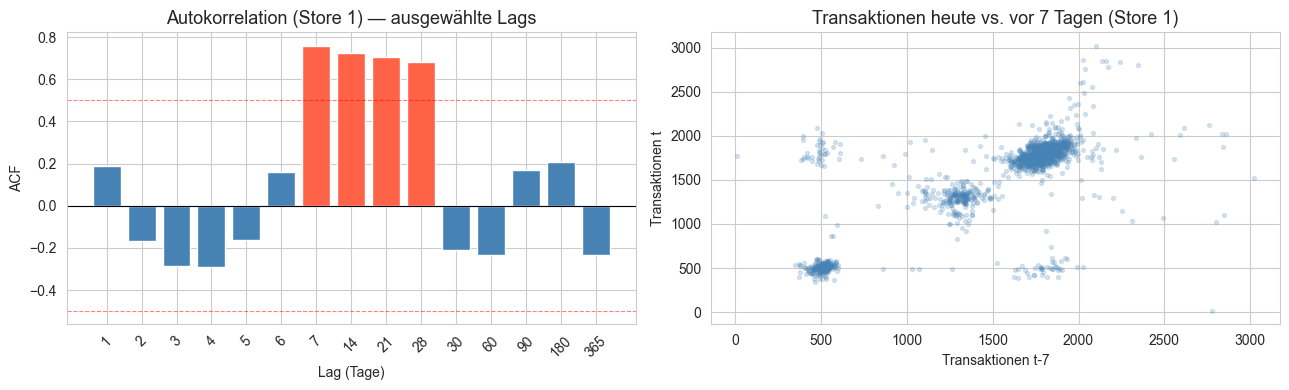

ACF-Werte:
  Lag   1: +0.189
  Lag   2: -0.169
  Lag   3: -0.288
  Lag   4: -0.291
  Lag   5: -0.162
  Lag   6: +0.158
  Lag   7: +0.759
  Lag  14: +0.726
  Lag  21: +0.706
  Lag  28: +0.683
  Lag  30: -0.210
  Lag  60: -0.234
  Lag  90: +0.170
  Lag 180: +0.206
  Lag 365: -0.234


In [8]:
# Store 1 als Beispiel (einer der vollständigsten Stores)
store1 = (
    tx.filter(pl.col('store_nbr') == 1)
    .sort('date')
    .to_pandas()
    .set_index('date')['transactions']
)

lags = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28, 30, 60, 90, 180, 365]
acf_vals = [store1.autocorr(lag=l) for l in lags]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ACF Barplot
colors = ['tomato' if abs(v) > 0.5 else 'steelblue' for v in acf_vals]
axes[0].bar([str(l) for l in lags], acf_vals, color=colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axhline(-0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title('Autokorrelation (Store 1) — ausgewählte Lags', fontsize=13)
axes[0].set_xlabel('Lag (Tage)')
axes[0].set_ylabel('ACF')
axes[0].tick_params(axis='x', rotation=45)

# Scatterplot: Lag 7 vs. aktueller Wert
axes[1].scatter(store1.shift(7), store1, alpha=0.2, s=8, color='steelblue')
axes[1].set_title('Transaktionen heute vs. vor 7 Tagen (Store 1)', fontsize=13)
axes[1].set_xlabel('Transaktionen t-7')
axes[1].set_ylabel('Transaktionen t')

plt.tight_layout()
plt.show()

print('ACF-Werte:')
for l, v in zip(lags, acf_vals):
    print(f'  Lag {l:>3}: {v:+.3f}')

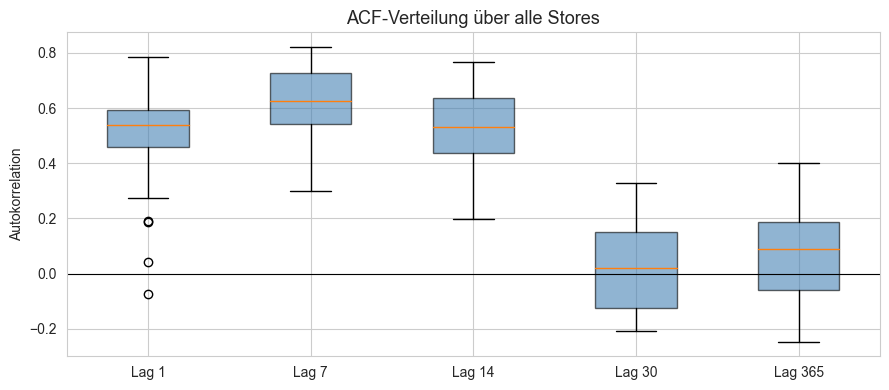

Median-ACF je Lag:
  Lag   1: median=+0.537  min=-0.075  max=+0.787
  Lag   7: median=+0.627  min=+0.301  max=+0.821
  Lag  14: median=+0.532  min=+0.197  max=+0.767
  Lag  30: median=+0.020  min=-0.210  max=+0.328
  Lag 365: median=+0.088  min=-0.246  max=+0.402


In [33]:
# ACF über alle Stores: Ist das Muster konsistent?
key_lags = [1, 7, 14, 30, 365]
acf_all = {lag: [] for lag in key_lags}

tx_pd = tx.to_pandas()
for store_id, grp in tx_pd.groupby('store_nbr'):
    s = grp.sort_values('date').set_index('date')['transactions']
    if len(s) < 400:   # Stores mit zu wenig Daten überspringen
        continue
    for lag in key_lags:
        if len(s) > lag:
            acf_all[lag].append(s.autocorr(lag=lag))

fig, ax = plt.subplots(figsize=(9, 4))
data_box = [acf_all[l] for l in key_lags]
bp = ax.boxplot(data_box, labels=[f'Lag {l}' for l in key_lags], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('ACF-Verteilung über alle Stores', fontsize=13)
ax.set_ylabel('Autokorrelation')
plt.tight_layout()
plt.show()

print('Median-ACF je Lag:')
for lag in key_lags:
    vals = acf_all[lag]
    print(f'  Lag {lag:>3}: median={np.median(vals):+.3f}  min={min(vals):+.3f}  max={max(vals):+.3f}')

## 5 · Externe Regressoren

### 5a · Ölpreis

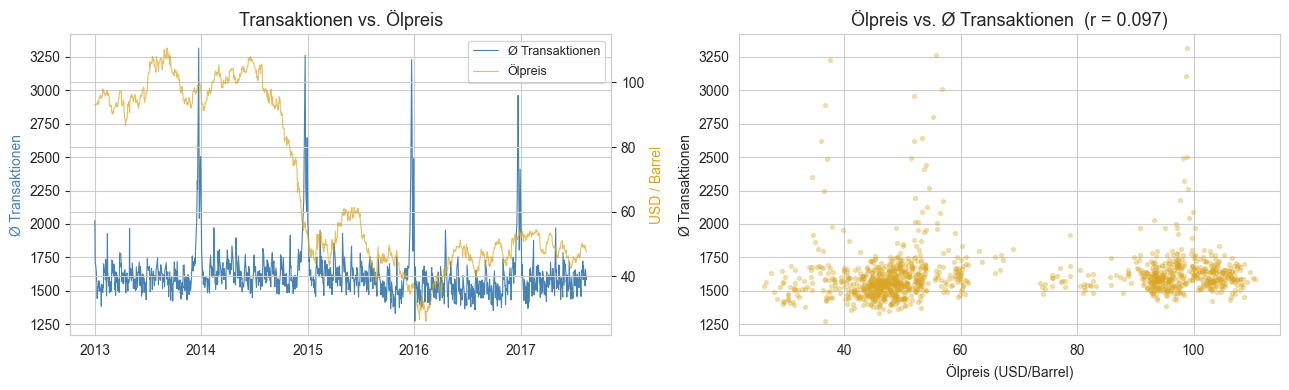

In [35]:
daily_avg = (
    tx.group_by('date')
    .agg(pl.col('transactions').mean().alias('avg_tx'))
    .sort('date')
    .to_pandas()
)

oil_pd = oil.to_pandas().dropna()
merged_oil = daily_avg.merge(oil_pd, on='date', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Zeitverlauf mit Twin-Achse
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(merged_oil['date'], merged_oil['avg_tx'],
         color='steelblue', linewidth=0.8, label='Ø Transaktionen')
ax2.plot(merged_oil['date'], merged_oil['dcoilwtico'],
         color='goldenrod', linewidth=0.8, alpha=0.7, label='Ölpreis')
ax1.set_title('Transaktionen vs. Ölpreis', fontsize=13)
ax1.set_ylabel('Ø Transaktionen', color='steelblue')
ax2.set_ylabel('USD / Barrel', color='goldenrod')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

# Scatterplot
axes[1].scatter(merged_oil['dcoilwtico'], merged_oil['avg_tx'],
                alpha=0.3, s=8, color='goldenrod')
corr = merged_oil[['dcoilwtico', 'avg_tx']].corr().iloc[0, 1]
axes[1].set_title(f'Ölpreis vs. Ø Transaktionen  (r = {corr:.3f})', fontsize=13)
axes[1].set_xlabel('Ölpreis (USD/Barrel)')
axes[1].set_ylabel('Ø Transaktionen')

plt.tight_layout()
plt.show()

### 5b · Feiertage

In [29]:
hol

date,type,locale,locale_name,description,transferred
date,str,str,str,str,bool
2012-03-02,"""Holiday""","""Local""","""Manta""","""Fundacion de Manta""",false
2012-04-01,"""Holiday""","""Regional""","""Cotopaxi""","""Provincializacion de Cotopaxi""",false
2012-04-12,"""Holiday""","""Local""","""Cuenca""","""Fundacion de Cuenca""",false
2012-04-14,"""Holiday""","""Local""","""Libertad""","""Cantonizacion de Libertad""",false
2012-04-21,"""Holiday""","""Local""","""Riobamba""","""Cantonizacion de Riobamba""",false
…,…,…,…,…,…
2017-12-22,"""Additional""","""National""","""Ecuador""","""Navidad-3""",false
2017-12-23,"""Additional""","""National""","""Ecuador""","""Navidad-2""",false
2017-12-24,"""Additional""","""National""","""Ecuador""","""Navidad-1""",false


In [43]:
hol_national = (
    hol.filter(pl.col('locale') == 'National')
    .select(['date', 'type'])
    .rename({'type': 'hol_type'})
).to_pandas()


df_hol = daily_avg.merge(hol_national, on='date', how='left')
df_hol["hol_type"] = df_hol["hol_type"].fillna("Normal", inplace = True)

df_hol

C:\Users\maxkr\AppData\Local\Temp\ipykernel_16480\1675174459.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_hol["hol_type"] = df_hol["hol_type"].fillna("Normal", inplace = True)


,date,avg_tx,hol_type
0,2013-01-01,770.000000,Holiday
1,2013-01-02,2026.413043,Normal
2,2013-01-03,1706.608696,Normal
3,2013-01-04,1706.391304,Normal
4,2013-01-05,2034.195652,Work Day
...,...,...,...
1681,2017-08-11,1658.351852,Transfer
1682,2017-08-12,1665.314815,Normal
1683,2017-08-13,1592.462963,Normal
1684,2017-08-14,1582.370370,Normal


C:\Users\maxkr\AppData\Local\Temp\ipykernel_16480\4147734298.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hol, x='hol_type', y='avg_tx', order=order,


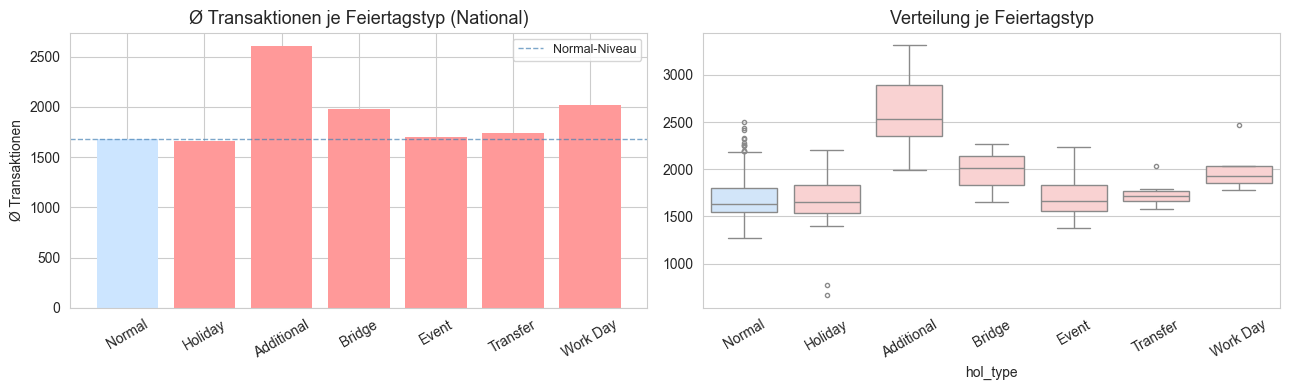

Mittelwert je Feiertagstyp (national):
              mean  count
hol_type                 
Additional  2607.5     29
Bridge      1977.3      3
Event       1700.6     56
Holiday     1658.1     46
Normal      1678.5   1540
Transfer    1741.6      7
Work Day    2014.4      5


In [44]:
# Nationale Feiertage joinen
# Reihenfolge für Plot
order = ['Normal', 'Holiday', 'Additional', 'Bridge', 'Event', 'Transfer', 'Work Day']
order = [o for o in order if o in df_hol['hol_type'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barplot Mittelwert je Typ
hol_avg = df_hol.groupby('hol_type')['avg_tx'].mean().reindex(order)
colors_bar = ['#cce5ff' if h == 'Normal' else '#ff9999' for h in order]
axes[0].bar(hol_avg.index, hol_avg.values, color=colors_bar, edgecolor='none')
axes[0].axhline(hol_avg['Normal'], color='steelblue', linestyle='--',
                linewidth=1, alpha=0.7, label='Normal-Niveau')
axes[0].set_title('Ø Transaktionen je Feiertagstyp (National)', fontsize=13)
axes[0].set_ylabel('Ø Transaktionen')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)

# Boxplot für Streuung
sns.boxplot(data=df_hol, x='hol_type', y='avg_tx', order=order,
            palette=['#cce5ff'] + ['#ffcccc'] * (len(order) - 1),
            flierprops={'markersize': 3}, ax=axes[1])
axes[1].set_title('Verteilung je Feiertagstyp', fontsize=13)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Mittelwert je Feiertagstyp (national):')
print(df_hol.groupby('hol_type')['avg_tx'].agg(['mean','count']).round(1))

## 6 · Store-Heterogenität

PatchTST wird über alle Stores trainiert. Wie unterschiedlich sind die Serien?

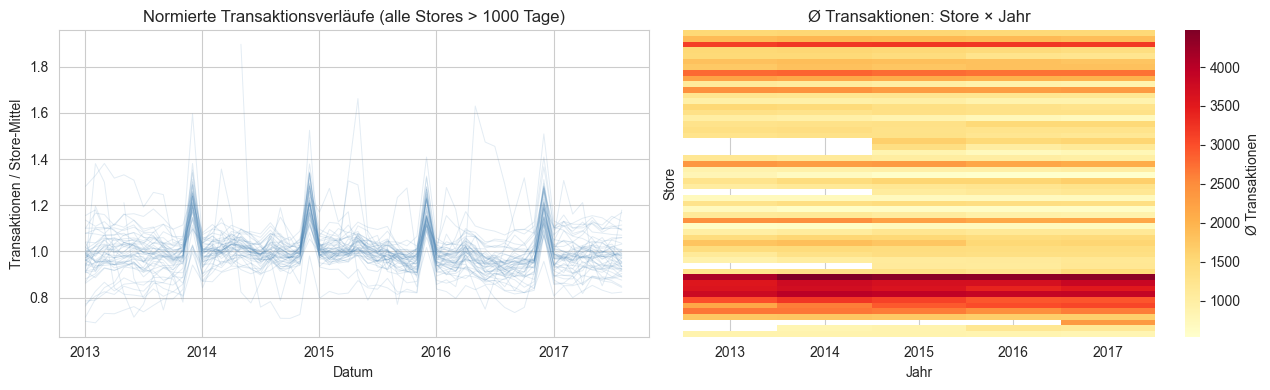

In [45]:
# Alle Stores übereinander (normiert auf ihren jeweiligen Mittelwert)
tx_pd = tx.to_pandas()

store_means = tx_pd.groupby('store_nbr')['transactions'].transform('mean')
tx_pd['tx_normalized'] = tx_pd['transactions'] / store_means

# Nur Stores mit > 1000 Tagen plotten
long_stores = tx_pd.groupby('store_nbr').filter(lambda g: len(g) > 1000)
monthly = (
    long_stores.assign(month=long_stores['date'].values.astype('datetime64[M]'))
    .groupby(['month', 'store_nbr'])['tx_normalized'].mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Normierte Verläufe
for store_id, grp in monthly.groupby('store_nbr'):
    axes[0].plot(grp['month'], grp['tx_normalized'],
                 alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].set_title('Normierte Transaktionsverläufe (alle Stores > 1000 Tage)', fontsize=12)
axes[0].set_ylabel('Transaktionen / Store-Mittel')
axes[0].set_xlabel('Datum')

# Heatmap Store × Jahr
store_year = (
    df.group_by(['store_nbr', 'year'])
    .agg(pl.col('transactions').mean().alias('avg'))
    .to_pandas()
    .pivot(index='store_nbr', columns='year', values='avg')
)
sns.heatmap(store_year, cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Ø Transaktionen'},
            xticklabels=True, yticklabels=False)
axes[1].set_title('Ø Transaktionen: Store × Jahr', fontsize=12)
axes[1].set_xlabel('Jahr')
axes[1].set_ylabel('Store')

plt.tight_layout()
plt.show()

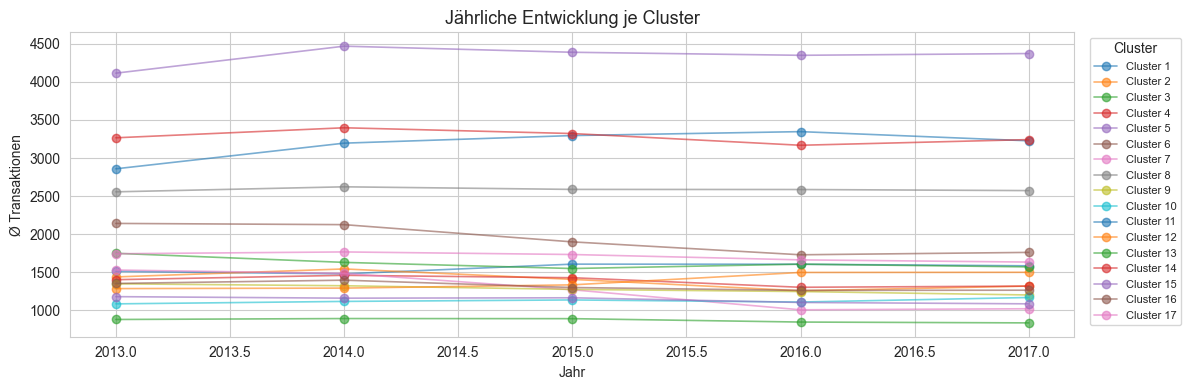

In [46]:
# Cluster-Vergleich: Ähneln sich Stores im selben Cluster tatsächlich?
cluster_avg = (
    df.group_by(['cluster', 'year'])
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort(['cluster', 'year'])
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(12, 4))
for cluster_id, grp in cluster_avg.groupby('cluster'):
    ax.plot(grp['year'], grp['avg'], marker='o', alpha=0.6,
            linewidth=1.2, label=f'Cluster {cluster_id}')
ax.set_title('Jährliche Entwicklung je Cluster', fontsize=13)
ax.set_ylabel('Ø Transaktionen')
ax.set_xlabel('Jahr')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left',
          ncol=1, fontsize=8)
plt.tight_layout()
plt.show()

## 7 · Fazit & Feature-Engineering-Entscheidungen

| Befund | Konsequenz für Notebook 03 |
|---|---|
| Starke Wochensaisonalität (ACF Lag 7 ≈ 0.76) | Lags: 1, 7, 14 sind Pflicht |
| Dezember-Peak sichtbar | Zyklische Monats-Features (sin/cos) |
| Samstag / Sonntag deutlich erhöht | Wochentag als kategorisches Feature |
| Ölpreis schwach korreliert (r ≈ 0.10) | Als exogener Regressor mit Interpolation aufnehmen |
| Feiertage: +12% im Mittel, `Additional` und `Work Day` am stärksten | Holiday-Flag + Typ als Feature |
| Stores unterscheiden sich im Level, nicht im Muster | Normierung oder Store-ID als kategorisches Embedding sinnvoll |
| Kein starker Jahres-Trend | Kein explizites Trend-Feature nötig |

In [47]:
# Basisanalyse als Parquet für spätere Referenz speichern
pl.from_pandas(daily_avg).write_parquet(PROCESSED / 'daily_avg_all_stores.parquet')
print('daily_avg_all_stores.parquet gespeichert.')

daily_avg_all_stores.parquet gespeichert.
